In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import CrackDectection
import random

In [10]:
img = cv2.imread("example/065.jpg", cv2.IMREAD_GRAYSCALE)
# img = cv2.imread("bitplane_results/bitplane_result.jpg", cv2.IMREAD_GRAYSCALE) 
if img is None:
    raise ValueError("Image not found or path is incorrect")
print(type(img))

<class 'numpy.ndarray'>


# Inpainting with window sliding using median

In [11]:
def inpaint_window_sliding_median(
    original_img,
    mask,
    step=6,
    ratio=0.05,
    max_size=181,
    neighbor_weight=0.6, 
    gaussian_ksize=9,
    gaussian_sigma=1.2):

    img = original_img.copy().astype(np.float32)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = img[..., np.newaxis]
        was_grayscale = True
        channels = 1
    else:
        was_grayscale = False
        channels = img.shape[2]

    mask_bool = (mask > 127)
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    # Known mask contain non-crack pixels
    known_mask = ~mask_bool.copy()

    crack_coords = list(zip(*np.where(mask_bool)))
    if not crack_coords:
        return original_img.astype(np.uint8)

    print(f"Median + Weighted Blend inpainting on {len(crack_coords)} pixels (neighbor_weight={neighbor_weight})...")

    neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    filled = 0
    for py, px in crack_coords:
        half_size = 0
        candidates_values = []

        while half_size <= (max_size // 2):
            y1 = max(0, py - half_size)
            y2 = min(h, py + half_size + 1)
            x1 = max(0, px - half_size)
            x2 = min(w, px + half_size + 1)

            square_area = (y2 - y1) * (x2 - x1)
            if square_area <= 1:
                half_size += step
                continue

            # Collect values from currently known pixels in square
            current_candidates = []
            for ky in range(y1, y2):
                for kx in range(x1, x2):
                    if known_mask[ky, kx]:
                        current_candidates.append(img[ky, kx])

            if len(current_candidates) >= ratio * square_area:
                candidates_values = np.array(current_candidates)
                break

            half_size += step

        # Fallback: use median of all known pixels if no local candidates
        if len(candidates_values) == 0:
            all_known = img[known_mask]
            if len(all_known) > 0:
                median_value = np.median(all_known, axis=0)
            else:
                median_value = np.zeros(channels)
        else:
            median_value = np.median(candidates_values, axis=0)

        # Get 8-neighbor values (already known, including previously filled)
        neighbor_values = []
        valid_neighbor_coords = []
        for dy, dx in neighbors:
            ny, nx = py + dy, px + dx
            if 0 <= ny < h and 0 <= nx < w and known_mask[ny, nx]:
                neighbor_values.append(img[ny, nx])
                valid_neighbor_coords.append((ny, nx))

        num_neighbors = len(neighbor_values)

        # Weighted blend
        final_value = median_value * (1.0 - neighbor_weight)

        if num_neighbors > 0:
            neighbor_contrib = np.mean(neighbor_values, axis=0)
            final_value += neighbor_contrib * neighbor_weight
        else:
            # Fully rely on median value in the window
            final_value += median_value * neighbor_weight
            
        # Assign
        img[py, px] = final_value

        # Update known mask
        known_mask[py, px] = True

        filled += 1
        if filled % 1000 == 0:
            print(f"  Progress: {filled}/{len(crack_coords)}")

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(f"Applying final targeted Gaussian (ksize={gaussian_ksize}, sigma={gaussian_sigma})...")
        blurred = cv2.GaussianBlur(img, (gaussian_ksize, gaussian_ksize), gaussian_sigma)

        if channels == 1:
            crack_mask_3d = mask_bool
        else:
            crack_mask_3d = np.repeat(mask_bool[..., np.newaxis], channels, axis=2)

        img[crack_mask_3d] = blurred[crack_mask_3d]

    result = np.clip(img, 0, 255).astype(np.uint8)
    if was_grayscale:
        result = result.squeeze()

    return result
    

# Inpainting with window sliding using random selection

In [ ]:
def inpaint_window_sliding_random(
    original_img,
    mask,
    step=5,
    ratio=0.05,
    max_size=151,
    neighbor_weight=0.4,        
    gaussian_ksize=9,
    gaussian_sigma=1.2,
    random_seed=50):
    
    if random_seed is not None:
        np.random.seed(random_seed)

    img = original_img.copy().astype(np.float32)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = img[..., np.newaxis]
        was_grayscale = True
        channels = 1
    else:
        was_grayscale = False
        channels = img.shape[2]

    # Original mask
    mask_bool = (mask > 127)
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    # Known mask = non-crack
    known_mask = ~mask_bool

    crack_coords = list(zip(*np.where(mask_bool)))
    if not crack_coords:
        return original_img.astype(np.uint8)

    print(f"Inpainting on {len(crack_coords)} crack pixels (neighbor weight={neighbor_weight})...")

    # 8-connectivity
    neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    filled = 0
    for py, px in crack_coords:
        # Grow square to find candidate known pixels
        half_size = 0
        candidates = []

        while half_size <= (max_size // 2) and not candidates:
            y1 = max(0, py - half_size)
            y2 = min(h, py + half_size + 1)
            x1 = max(0, px - half_size)
            x2 = min(w, px + half_size + 1)

            square_area = (y2 - y1) * (x2 - x1)
            if square_area <= 1:
                half_size += step
                continue

            # Collect currently known pixels in square
            for ky in range(y1, y2):
                for kx in range(x1, x2):
                    if known_mask[ky, kx]:
                        candidates.append((ky, kx))

            if len(candidates) < ratio * square_area:
                candidates = []

            half_size += step

        # If still no candidates, use any known pixel in image
        if not candidates:
            known_flat = list(zip(*np.where(known_mask)))
            if known_flat:
                candidates = [random.choice(known_flat)]

        if not candidates:
            filled += 1
            continue

        # Randomly select one main texture pixel
        main_ky, main_kx = random.choice(candidates)
        main_value = img[main_ky, main_kx]

        # Collect 8-neighbors that are already known
        neighbor_values = []
        for dy, dx in neighbors:
            ny, nx = py + dy, px + dx
            if 0 <= ny < h and 0 <= nx < w and known_mask[ny, nx]:
                neighbor_values.append(img[ny, nx])

        num_neighbors = len(neighbor_values)
        blended = main_value * (1 - neighbor_weight)

        if num_neighbors > 0:
            blended += np.mean(neighbor_values, axis=0) * neighbor_weight
        else:
            blended = main_value

        # Assign
        img[py, px] = blended

        # Update known mask
        known_mask[py, px] = True

        filled += 1
        if filled % 1000 == 0:
            print(f"  Progress: {filled}/{len(crack_coords)}")

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(f"Applying final targeted Gaussian (ksize={gaussian_ksize}, sigma={gaussian_sigma})...")
        blurred = cv2.GaussianBlur(img, (gaussian_ksize, gaussian_ksize), gaussian_sigma)

        # Mask for original crack pixels
        if channels == 1:
            crack_mask_3d = mask_bool
        else:
            crack_mask_3d = np.repeat(mask_bool[..., np.newaxis], channels, axis=2)

        img[crack_mask_3d] = blurred[crack_mask_3d]

    result = np.clip(img, 0, 255).astype(np.uint8)
    if was_grayscale:
        result = result.squeeze()

    return result


# 8-bit plane splitting

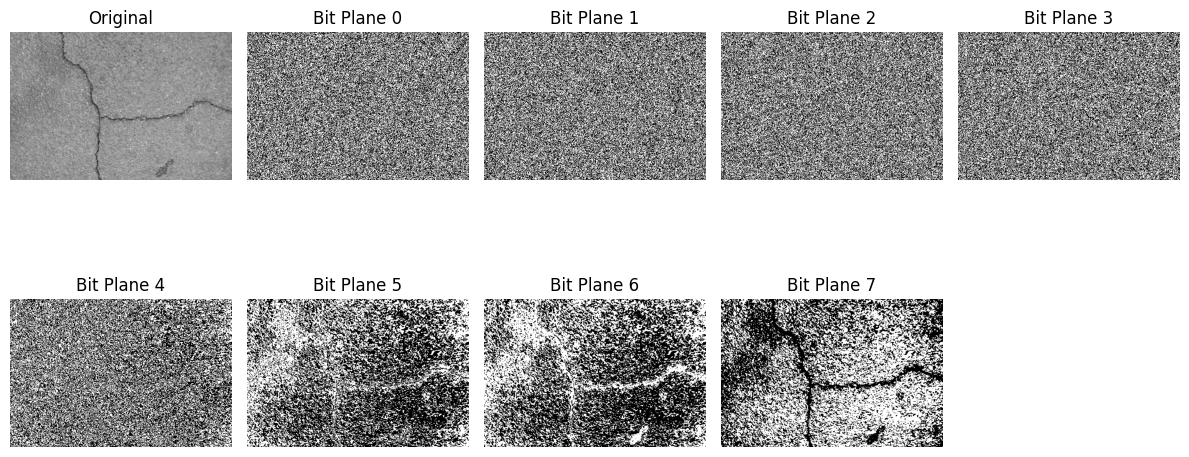

In [13]:
# Create bit planes
bit_planes = []
for i in range(8):
    # Extract bit-plane i
    bit_plane = (img >> i) & 1
    bit_planes.append(bit_plane)

# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(2, 5, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(bit_planes[i] * 255, cmap="gray")
    plt.title(f"Bit Plane {i}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("result/bit_planes.png")
plt.show()

# Inpainting with reflection

In [14]:
def inpaint_with_reflection(
    original_img: np.ndarray,
    mask: np.ndarray,
    window_size=21,
    stride=5,
    priority="horizontal",
    gaussian_ksize=11,
    gaussian_sigma=1.0,
):
    if window_size % 2 == 0:
        raise Exception("Window size needs to be an odd number")
    if gaussian_ksize % 2 == 0:
        raise Exception("Gaussian kernel needs to be an odd number")

    img = original_img.copy().astype(np.uint8)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.uint8)
        was_grayscale = True
        channels = 3
    else:
        was_grayscale = False
        channels = img.shape[2]

    mask_bool = mask > 127
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    original_mask_bool = mask_bool.copy()

    half_win = window_size // 2

    directions = (
        ["horizontal", "vertical"]
        if priority == "horizontal"
        else ["vertical", "horizontal"]
    )

    print("Inpainting bitplane...")
    result = np.zeros_like(img)
    for c in range(channels):
        channel = img[:, :, c]

        bit_planes = [(channel & (1 << b)) >> b for b in range(8)]

        processed_planes = []
        for bp in bit_planes:
            bp_processed = bp.copy()
            mask_processed = mask_bool.copy()

            for y in range(half_win, h - half_win, stride):
                for x in range(half_win, w - half_win, stride):
                    y1 = y - half_win
                    y2 = y + half_win + 1
                    x1 = x - half_win
                    x2 = x + half_win + 1

                    mask_window = mask_processed[y1:y2, x1:x2]

                    if not np.any(mask_window):
                        continue

                    for ry in range(window_size):
                        for rx in range(window_size):
                            if mask_window[ry, rx]:
                                py = y1 + ry
                                px = x1 + rx

                                for dir in directions:
                                    if dir == "horizontal":  # Horizontal reflection
                                        refl_rx = 2 * half_win - rx
                                        refl_ry = ry
                                    else:  # Vertical reflection
                                        refl_rx = rx
                                        refl_ry = 2 * half_win - ry

                                    # Absolute coordinate
                                    source_y = y1 + refl_ry
                                    source_x = x1 + refl_rx

                                    if 0 <= source_y < h and 0 <= source_x < w:
                                        if not mask_processed[source_y, source_x]:
                                            bp_processed[py, px] = bp[
                                                source_y, source_x
                                            ]
                                            mask_processed[py, px] = False
                                            break

            processed_planes.append(bp_processed)

        # Reconstruct
        reconstructed = np.zeros((h, w), dtype=np.uint8)
        for b in range(8):
            reconstructed |= processed_planes[b] << b

        result[:, :, c] = reconstructed

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(
            f"Gaussian blur (ksize={gaussian_ksize}, sigma={gaussian_sigma}) to crack regions..."
        )
        blurred = cv2.GaussianBlur(
            result, (gaussian_ksize, gaussian_ksize), gaussian_sigma
        )

        if channels == 1:
            crack_mask_3d = original_mask_bool
        else:
            crack_mask_3d = np.repeat(
                original_mask_bool[..., np.newaxis], channels, axis=2
            )

        result[crack_mask_3d] = blurred[crack_mask_3d]

    if was_grayscale:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    return result


# Inpainting with reflection and gradient

In [15]:
def inpaint_with_gradient(
    original_img: np.ndarray,
    mask: np.ndarray,
    window_size=21,
    stride=5,
    priority="horizontal",
    gaussian_ksize=11,
    gaussian_sigma=1.0,
):
    if window_size % 2 == 0:
        raise Exception("Window size needs to be an odd number")
    if gaussian_ksize % 2 == 0:
        raise Exception("Gaussian kernel needs to be an odd number")

    img = original_img.copy().astype(np.uint8)
    h, w = img.shape[:2]

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.uint8)
        was_grayscale = True
        channels = 3
    else:
        was_grayscale = False
        channels = img.shape[2]

    mask_bool = mask > 127
    if mask_bool.ndim == 3:
        mask_bool = mask_bool.squeeze()

    original_mask_bool = mask_bool.copy()

    half_win = window_size // 2

    # Precompute gradient magnitude and angle on grayscale version
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if channels == 3 else img.squeeze()
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.hypot(sobelx, sobely)
    grad_ang = np.arctan2(sobely, sobelx)  # -pi to pi

    result = np.zeros_like(img)

    for c in range(channels):
        channel = img[:, :, c]
        bit_planes = [(channel & (1 << b)) >> b for b in range(8)]

        processed_planes = []
        for bp in bit_planes:
            bp_processed = bp.copy()
            mask_processed = mask_bool.copy()

            for y in range(half_win, h - half_win, stride):
                for x in range(half_win, w - half_win, stride):
                    y1 = y - half_win
                    y2 = y + half_win + 1
                    x1 = x - half_win
                    x2 = x + half_win + 1

                    mask_window = mask_processed[y1:y2, x1:x2]
                    if not np.any(mask_window):
                        continue

                    # Local gradient
                    local_ang = grad_ang[y1:y2, x1:x2]
                    local_mag = grad_mag[y1:y2, x1:x2]

                    # Weighted average angle
                    angles = local_ang.flatten()
                    weights = local_mag.flatten()
                    if np.sum(weights) > 0:
                        mean_angle = np.arctan2(
                            np.sum(weights * np.sin(angles)),
                            np.sum(weights * np.cos(angles)),
                        )
                    else:
                        mean_angle = 0

                    if abs(np.cos(mean_angle)) > abs(np.sin(mean_angle)):
                        # Dominant horizontal gradient → vertical crack → horizontal reflection
                        directions = ["horizontal", "vertical"]
                    elif (np.cos(mean_angle)) < abs(np.sin(mean_angle)):
                        # Dominant vertical gradient → horizontal crack → vertical reflection
                        directions = ["vertical", "horizontal"]
                    else:
                        if priority == "horizontal":
                            directions = ["horizontal", "vertical"]
                        else:
                            directions = ["vertical", "horizontal"]

                    for ry in range(window_size):
                        for rx in range(window_size):
                            if not mask_window[ry, rx]:
                                continue

                            py = y1 + ry
                            px = x1 + rx

                            filled = False
                            for dir in directions:
                                if dir == "horizontal":
                                    refl_rx = 2 * half_win - rx
                                    refl_ry = ry
                                else:
                                    refl_rx = rx
                                    refl_ry = 2 * half_win - ry

                                source_y = y1 + refl_ry
                                source_x = x1 + refl_rx

                                if 0 <= source_y < h and 0 <= source_x < w:
                                    if not mask_processed[source_y, source_x]:
                                        bp_processed[py, px] = bp[
                                            source_y, source_x
                                        ]
                                        mask_processed[py, px] = False
                                        filled = True
                                        break

            processed_planes.append(bp_processed)

        # Reconstruct
        reconstructed = np.zeros((h, w), dtype=np.uint8)
        for b in range(8):
            reconstructed |= processed_planes[b] << b

        result[:, :, c] = reconstructed

    # Gaussian smoothing
    if gaussian_ksize > 1:
        print(f"Gaussian blur (ksize={gaussian_ksize}, sigma={gaussian_sigma})...")
        blurred = cv2.GaussianBlur(
            result, (gaussian_ksize, gaussian_ksize), gaussian_sigma
        )

        crack_mask_3d = (
            original_mask_bool[..., np.newaxis]
            if channels > 1
            else original_mask_bool
        )
        if channels > 1:
            crack_mask_3d = np.repeat(crack_mask_3d, channels, axis=2)

        result[crack_mask_3d] = blurred[crack_mask_3d]

    if was_grayscale:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    return result


# Test approaches

Median + Weighted Blend inpainting on 9263 pixels (neighbor_weight=0.1)...
  Progress: 1000/9263
  Progress: 2000/9263
  Progress: 3000/9263
  Progress: 4000/9263
  Progress: 5000/9263
  Progress: 6000/9263
  Progress: 7000/9263
  Progress: 8000/9263
  Progress: 9000/9263
Applying final targeted Gaussian (ksize=15, sigma=0.5)...
Smart weighted inpainting on 9263 crack pixels (neighbor weight=0.1)...
  Progress: 1000/9263
  Progress: 2000/9263
  Progress: 3000/9263
  Progress: 4000/9263
  Progress: 5000/9263
  Progress: 6000/9263
  Progress: 7000/9263
  Progress: 8000/9263
  Progress: 9000/9263
Applying final targeted Gaussian (ksize=15, sigma=0.5)...
Gaussian blur (ksize=5, sigma=0.2)...
Inpainting bitplane...
Gaussian blur (ksize=5, sigma=0.2) to crack regions...


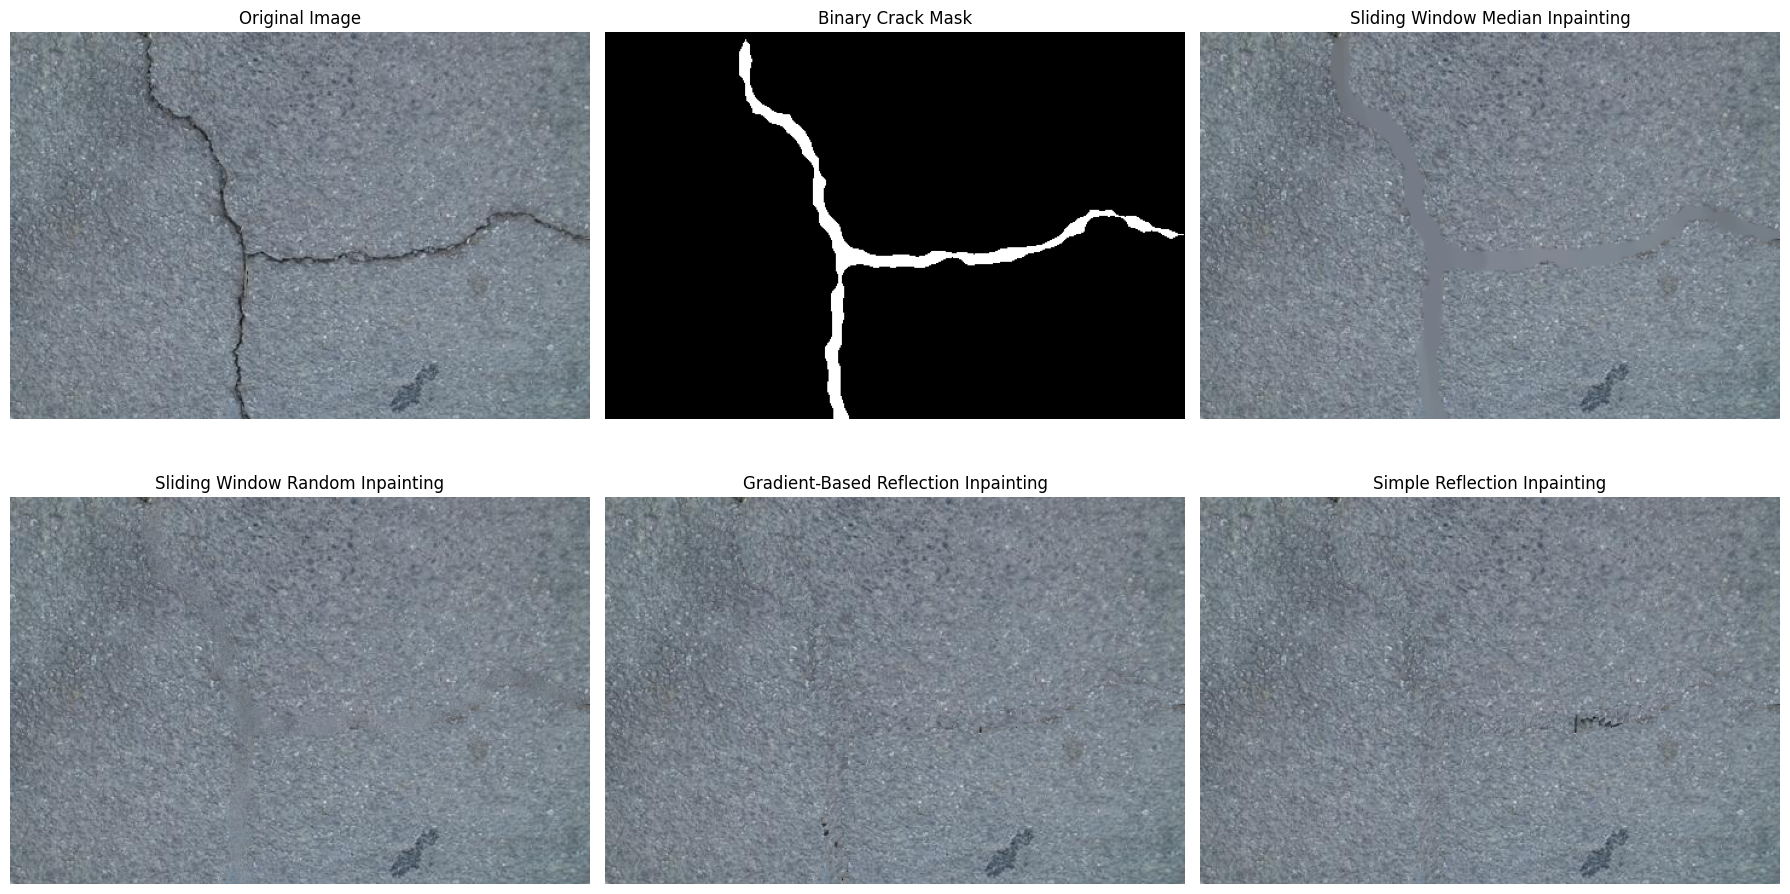

In [ ]:
image_path = "example/065.jpg"
output_dir = "result_inpainting"

crack_detection_obj = CrackDectection()
original, final_mask = crack_detection_obj.crack_hist_clip(image_path, output_dir)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask_dilated = cv2.dilate(final_mask, kernel, iterations=1)

win_media = inpaint_window_sliding_median(
    original,
    mask_dilated,
    step=6,
    ratio=0.05,
    max_size=101,
    neighbor_weight=0.1,
    gaussian_ksize=15,
    gaussian_sigma=0.5
)

win_random = inpaint_window_sliding_random(
    original,
    mask_dilated,
    step=6,
    ratio=0.05,
    max_size=101,
    neighbor_weight=0.1,
    gaussian_ksize=15,
    gaussian_sigma=0.5
)

reflect_simple = inpaint_with_reflection(
    original,
    mask_dilated,
    window_size=125,
    stride=5,
    priority="horizontal",
    gaussian_ksize=5,
    gaussian_sigma=0.2,
)

reflect_gradient = inpaint_with_gradient(
    original,
    mask_dilated,
    window_size=125,
    stride=5,
    priority="horizontal",
    gaussian_ksize=5,
    gaussian_sigma=0.2,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()  # Flatten for easy indexing

images = [
    cv2.cvtColor(original, cv2.COLOR_BGR2RGB),
    final_mask,
    cv2.cvtColor(win_media, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(win_random, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(reflect_simple, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(reflect_gradient, cv2.COLOR_BGR2RGB),
]

titles = [
    "Original Image",
    "Binary Crack Mask",
    "Sliding Window Median Inpainting",
    "Sliding Window Random Inpainting",
    "Simple Reflection Inpainting",
    "Gradient-Based Reflection Inpainting",
]

for ax, img, title in zip(axes, images, titles):
    if img.ndim == 2:  # grayscale (mask)
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{output_dir}/grid.png")
plt.show()